# Characteristic Strain vs Galactic Binary Foreground

Do the massive black hole binaries (MBHBs) overlap the galactic binary (GB) foreground when we cut them off before merger?

Here we plot the characteristic strains of each signal, with the different days-before-merger cutoffs, against the LISA A/E modelled PSDs **with** and **without** GBs. The characteristic strain is converted to $h_c^2/f$ so that it sits on the same scale as the PSDs, making any overlap with the GB foreground immediately visible.

We then quantify this by computing the expected SNR of each signal at each cutoff in both cases:

* **Without GBs**: matched-filter SNR against the clean instrument noise model (`model_AE_NOGB_PSD.txt`)
* **With GBs**: matched-filter SNR against the full model including the galactic binary confusion noise (`model_AE_PSD.txt`). Note that this doesn't take into account the resolvable binaries

The difference between these two is the expected SNR loss due to the GB confusion noise at pre-merger times.


In [10]:
import pycbc.psd
from pycbc.conversions import mchirp_from_mass1_mass2 as mchirp
import numpy as np

from matplotlib import pyplot as plt
plt.style.use('../paper.mplstyle')

import sys
import os

search_dir = os.path.abspath("../search")

if search_dir not in sys.path:
    sys.path.insert(0, search_dir)

import plotting_utils

import h5py

# days before merger to use as cutoffs (must match characteristic_strain.py)
cutoff_days = [0.5, 1, 4, 7, 14]

# signals in the collected characteristic strain file
signals = range(15)

paper_plots_dir = "../paper/images/"


## Load the model PSDs and characteristic strains


In [11]:
# Load in PSD files (same loading pattern as plot_psds.ipynb)
duration = 365 * 86400
delta_t = 5
flen = int(duration / delta_t) // 2 + 1
delta_f = 1 / duration


def load_psd(filename, flen, delta_f):
    return pycbc.psd.from_txt(
        filename,
        flen,
        delta_f,
        delta_f,
        is_asd_file=False
    )


# Model A/E PSDs: with and without the galactic binary foreground
AE_model = load_psd('model_AE_PSD.txt', flen=flen, delta_f=delta_f)
AE_model_nogb = load_psd('model_AE_NOGB_PSD.txt', flen=flen, delta_f=delta_f)


In [12]:
# Load the collected characteristic strains (root-sum-square of A and E channels)
hc_all = {}

with h5py.File('characteristic_strain/collected_characteristic_strain.hdf', 'r') as ccsf:
    freqs = ccsf['frequencies'][:]
    valid = freqs > 0
    freqs = freqs[valid]

    for sig_num in signals:
        print(f'Signal {sig_num}')
        hc_all[sig_num] = {}
        grp = ccsf[str(sig_num)]
        for cutoff_day in cutoff_days + [0]:
            # channels are stored separately, root sum square to get overall strain
            hc_all[sig_num][cutoff_day] = \
                np.sqrt(
                    grp[str(cutoff_day).replace('.', 'p') + '_A'][valid] ** 2 +
                    grp[str(cutoff_day).replace('.', 'p') + '_E'][valid] ** 2
                )


# The model PSDs are on a slightly different frequency grid than the collected
# characteristic strain, so interpolate them onto the HDF frequencies (in log space)
psd_valid = AE_model.sample_frequencies > 0
AE_model_at_freqs = np.exp(
    np.interp(np.log(freqs), np.log(AE_model.sample_frequencies[psd_valid]), np.log(AE_model[psd_valid]))
)
AE_model_nogb_at_freqs = np.exp(
    np.interp(np.log(freqs), np.log(AE_model_nogb.sample_frequencies[psd_valid]), np.log(AE_model_nogb[psd_valid]))
)

# Downsample the frequency axis for plotting only. The full grid has ~3.15e6
# points, and drawing many such curves (one per signal and cutoff) as vector
# paths overwhelms the notebook frontend. We never downsample the arrays used
# for the SNR integrals below -- those stay at full resolution.
plot_stride = 5
freqs_plot = freqs[::plot_stride]
AE_model_at_freqs_plot = AE_model_at_freqs[::plot_stride]
AE_model_nogb_at_freqs_plot = AE_model_nogb_at_freqs[::plot_stride]

Signal 0


KeyboardInterrupt: 

In [ ]:
# Get the truth times of the signals from the Sangria dataset (for labelling)
import ldc.io.hdf5 as hdfio

input_data = '../datasets/LDC2_sangria_hm_training.hdf'  # The Sangria dataset
mbhb_sky, _ = hdfio.load_array(input_data, name="sky/mbhb/cat")

truth_times_days = mbhb_sky['CoalescenceTime'] / 86400
truth_mchirp = mchirp(mbhb_sky['Mass1'][:], mbhb_sky['Mass2'][:])


# Do the MBHBs overlap the GB foreground?

The characteristic strain $h_c$ is converted to a PSD-like quantity $h_c^2/f$, which is the signal power spectral density. Plotting this against the model A/E PSDs (with and without GBs) shows directly where the MBHB signal sits relative to the galactic binary foreground.


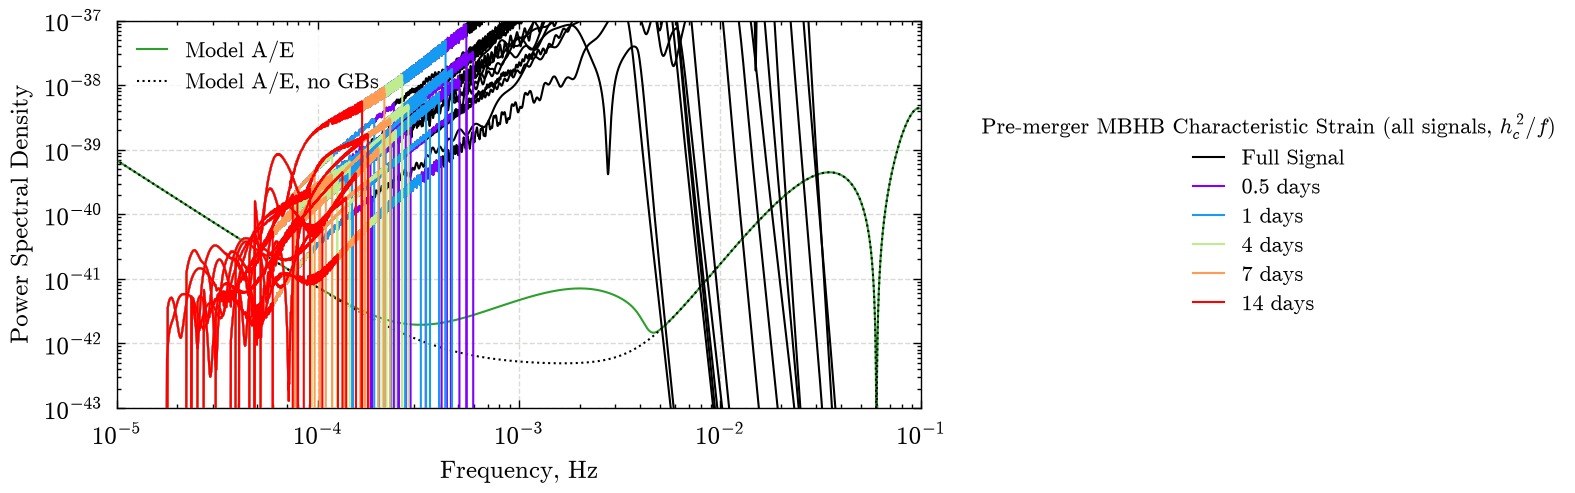

In [ ]:
def plot_psd_lines(ax):
    """Plot the model A/E PSDs with and without GBs (same style as plot_psds.ipynb)."""
    lines_to_plot = (
        (AE_model, 'Model A/E', 'tab:green', '-'),
        (AE_model_nogb, 'Model A/E, no GBs', 'k', ':'),
    )

    for psd, label, c, linestyle in lines_to_plot:
        ax.loglog(
            psd.sample_frequencies,
            psd,
            c=c,
            label=label,
            linestyle=linestyle,
            rasterized=True,
        )

    return ax.legend(loc='upper left')


# colour for each days-before-merger cutoff (same palette as the rest of the paper)
time_before_colors = plotting_utils.get_colors(cutoff_days)
time_before_colors[0] = 'k'

paper_example_signal = 2

width = plt.rcParams["figure.figsize"][0] * 1.5
height = plt.rcParams["figure.figsize"][1] * 1.25
fig, ax = plt.subplots(1, figsize=(width, height))

leg1 = plot_psd_lines(ax)

# Plot the characteristic strain as h_c^2/f so it sits on the PSD scale
line2 = []
labels2 = []
line2.append(
    ax.loglog(
        [],
        [],
        color='k',
    )[0]
)
labels2.append('Full Signal')

for days in cutoff_days:
    line2.append(
        ax.loglog(
            [],
            [],
            color=time_before_colors[days],
        )[0]
    )
    labels2.append(f'{days} days')


for signal_number in signals:

    ax.loglog(
        freqs[::plot_stride],
        hc_all[signal_number][0][::plot_stride] ** 2 / freqs[::plot_stride],
        color='k',
        zorder=40,
        rasterized=True
    )

    for days in cutoff_days:
        ax.loglog(
            freqs[::plot_stride],
            hc_all[signal_number][days][::plot_stride] ** 2 / freqs[::plot_stride],
            color=time_before_colors[days],
            zorder=40 + days,
            rasterized=True
        )

leg2 = ax.legend(
    line2,
    labels2,
    loc="center left",
    title="Pre-merger MBHB Characteristic Strain (all signals, $h_c^2/f$)",
    bbox_to_anchor=(1.05, 0.5),
)
ax.add_artist(leg1)

ax.set_ylabel("Power Spectral Density")
ax.set_xlabel("Frequency, Hz")
ax.set_ylim([1e-43, 1e-37])
ax.set_xlim([1e-5, 1e-1])
ax.grid(zorder=-100)

plt.show()


The MBHB characteristic strain sits well below the GB foreground at all pre-merger times shown here -- the signal is separate from the galactic binary noise, so this isn't a 'global fit' problem.


## Characteristic strain view

The same information in the characteristic-strain frame: $h_c$ for each cutoff against the characteristic noise curves $h_n = \sqrt{f S_n}$ for both models. The expected SNR is approximately the area between the signal and noise curves.

We also add the information that we colour the signals by chirp mass, so we see that the 


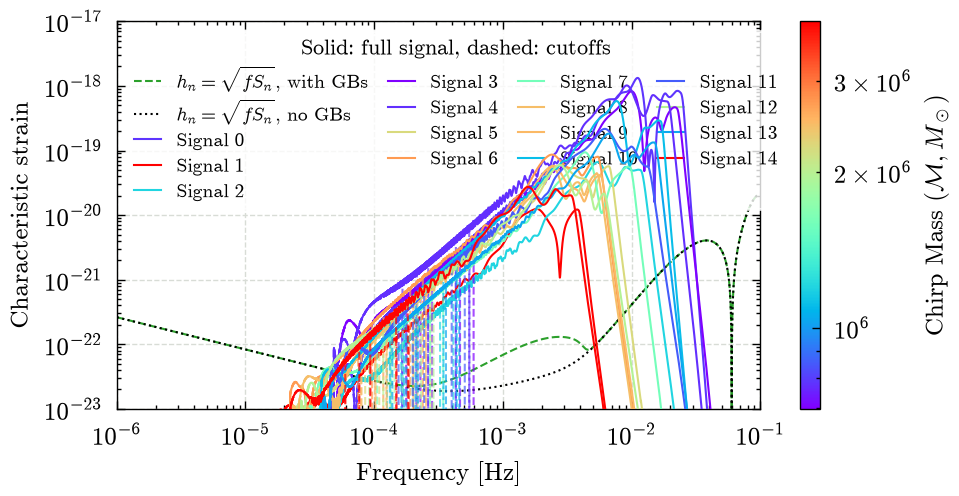

In [ ]:
# Characteristic noise curves for both models (downsampled for plotting)
hn_withgb = np.sqrt(freqs_plot * AE_model_at_freqs_plot)
hn_nogb = np.sqrt(freqs_plot * AE_model_nogb_at_freqs_plot)

from matplotlib.colors import LogNorm

# One colour per signal so all 15 are distinguishable on a single figure
norm = LogNorm(vmin=min(truth_mchirp), vmax=max(truth_mchirp))
signal_cmap = plt.get_cmap('rainbow')
signal_colors = {sig_num: signal_cmap(norm(truth_mchirp[i])) for i, sig_num in enumerate(signals)}

width = plt.rcParams["figure.figsize"][0] * 1.5
height = plt.rcParams["figure.figsize"][1] * 1.25
fig, ax = plt.subplots(1, figsize=(width, height))

# Noise curves (dashed)
ax.loglog(
    freqs_plot,
    hn_withgb,
    color='tab:green',
    linestyle='--',
    label=r'$h_n = \sqrt{f S_n}$, with GBs',
    rasterized=True
)
ax.loglog(
    freqs_plot,
    hn_nogb,
    color='k',
    linestyle=':',
    label=r'$h_n = \sqrt{f S_n}$, no GBs',
    rasterized=True
)

# Characteristic strain for every signal (full + each days-before-merger cutoff)
for sig_num in signals:
    ax.loglog(
        freqs_plot,
        hc_all[sig_num][0][::plot_stride],
        color=signal_colors[sig_num],
        label=f'Signal {sig_num}',
        zorder=40 + sig_num,
        rasterized=True
    )
    for days in cutoff_days:
        ax.loglog(
            freqs_plot,
            hc_all[sig_num][days][::plot_stride],
            color=signal_colors[sig_num],
            linestyle='--',
            alpha=0.7,
            zorder=40 + sig_num,
            rasterized=True
        )

# 2. Add the colorbar properly using a ScalarMappable
sm = plt.cm.ScalarMappable(cmap=signal_cmap, norm=norm)
cb = fig.colorbar(sm, ax=ax)
cb.set_label('Chirp Mass ($\mathcal{M}, M_\odot $)') # Customize label as needed

ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('Characteristic strain')
ax.set_ylim(1e-23, 1e-17)
ax.set_xlim(1e-6, 0.1)
ax.legend(
    loc='upper left',
    ncol=4,
    fontsize=7,
    title='Solid: full signal, dashed: cutoffs',
)
ax.grid(zorder=-100)

plt.show()

# Expected SNR loss from the GB foreground

The expected (matched-filter) SNR of a signal with characteristic strain $h_c$ in noise with PSD $S_n$ is

$$
\rho^2 = 4 \int_0^\infty \frac{h_c^2}{f S_n}\, df
$$

which we evaluate with trapezoid integration in log-frequency (the same method used in `characteristic_strain.ipynb`). We compute this for every signal and every days-before-merger cutoff against both the no-GB model and the with-GB model. The difference is the expected SNR loss from treating the GB foreground as additional noise.


In [ ]:
def expected_snr(h_c, psd):
    """
    Expected matched-filter SNR from the characteristic strain.

    rho^2 = 4 * integral h_c^2 / (f S_n) df, integrated in log-frequency
    (same convention as characteristic_strain.ipynb).
    """
    valid = psd > 0
    snr2 = np.trapezoid(
        (h_c[valid] ** 2) / (freqs[valid] * psd[valid]),
        np.log(freqs[valid]),
    )
    return np.sqrt(snr2)


# Expected SNR for each signal and cutoff, with and without GBs
snr_nogb = {}
snr_withgb = {}
for sig_num in signals:
    snr_nogb[sig_num] = {}
    snr_withgb[sig_num] = {}
    for cutoff_day in [0] + cutoff_days:
        h_c = hc_all[sig_num][cutoff_day]
        snr_nogb[sig_num][cutoff_day] = expected_snr(h_c, AE_model_nogb_at_freqs)
        snr_withgb[sig_num][cutoff_day] = expected_snr(h_c, AE_model_at_freqs)


## Table of expected SNRs

Expected SNR for each signal and days-before-merger cutoff, without GBs (clean model) and with GBs (full model), plus the fractional loss $1 - \rho_{\rm{with\ GB}}/\rho_{\rm{no\ GB}}$.


In [ ]:
table_str = """\\begin{tabular}{|cc|ccc|ccc|ccc|}
\\hline
\\multicolumn{2}{|c|}{Signal} & \\multicolumn{9}{c|}{Expected SNR (no GBs / with GBs / loss)} \\\\\
\\hline
Number & Time  & 0.5 noGB & 0.5 wGB & 0.5 loss & 1 noGB & 1 wGB & 1 loss & 4 noGB & 4 wGB & 4 loss \\\\\
\\hline
"""
for sig_num, days in zip(signals, truth_times_days):
    table_row = f"{sig_num} & {days:.2f}"
    for cutoff_day in cutoff_days:
        snr_no = snr_nogb[sig_num][cutoff_day]
        snr_gb = snr_withgb[sig_num][cutoff_day]
        loss = 1.0 - snr_gb / snr_no
        table_row += f" & {snr_no:.2f} & {snr_gb:.2f} & {loss:.3f}"
    table_row += " \\\\\n"
    table_str += table_row
table_str += """\\hline
\\end{tabular}"""

# Save for direct use in the paper, this helps prevent any copy/paste hiccups
print(table_str)


\begin{tabular}{|cc|ccc|ccc|ccc|}
\hline
\multicolumn{2}{|c|}{Signal} & \multicolumn{9}{c|}{Expected SNR (no GBs / with GBs / loss)} \\\hline
Number & Time  & 0.5 noGB & 0.5 wGB & 0.5 loss & 1 noGB & 1 wGB & 1 loss & 4 noGB & 4 wGB & 4 loss \\\hline
0 & 55.56 & 110.94 & 70.99 & 0.360 & 71.61 & 52.74 & 0.263 & 26.97 & 24.33 & 0.098 & 17.42 & 16.43 & 0.057 & 9.78 & 9.51 & 0.027 \\
1 & 101.23 & 4.15 & 3.99 & 0.038 & 2.54 & 2.49 & 0.019 & 0.79 & 0.79 & 0.004 & 0.47 & 0.47 & 0.002 & 0.28 & 0.28 & 0.000 \\
2 & 129.26 & 14.31 & 10.76 & 0.249 & 8.98 & 7.52 & 0.163 & 3.05 & 2.91 & 0.047 & 1.89 & 1.84 & 0.024 & 1.08 & 1.07 & 0.009 \\
3 & 130.31 & 116.90 & 71.92 & 0.385 & 76.88 & 54.76 & 0.288 & 30.89 & 27.52 & 0.109 & 21.20 & 19.88 & 0.062 & 13.62 & 13.22 & 0.029 \\
4 & 133.41 & 179.01 & 115.99 & 0.352 & 118.73 & 88.26 & 0.257 & 48.51 & 44.03 & 0.092 & 33.42 & 31.66 & 0.053 & 21.00 & 20.47 & 0.025 \\
5 & 138.55 & 18.39 & 16.40 & 0.108 & 11.48 & 10.79 & 0.059 & 3.90 & 3.85 & 0.013 & 2.38 & 2.37 &

## Fractional SNR loss vs time before merger

Finally, the fractional loss $1 - \rho_{\rm{with\ GB}}/\rho_{\rm{no\ GB}}$ for each signal. This directly quantifies how much of the expected SNR is lost to the GB foreground at pre-merger times.


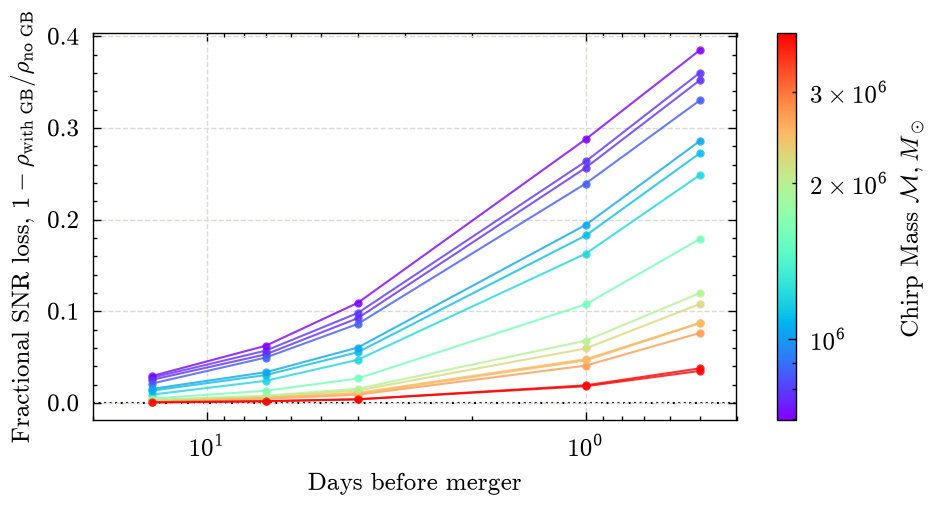

In [ ]:
width = plt.rcParams["figure.figsize"][0] * 1.5
height = plt.rcParams["figure.figsize"][1] * 1.25
fig, ax = plt.subplots(1, figsize=(width, height))


for sig_num in signals:
    loss_days = [
        1.0 - snr_withgb[sig_num][d] / snr_nogb[sig_num][d]
        for d in cutoff_days
    ]
    ax.plot(
        cutoff_days,
        loss_days,
        marker='o',
        markersize=2,
        alpha=0.8,
        c=signal_colors[sig_num],
        zorder=30
    )

ax.axhline(0, color='k', linestyle=':', zorder=0)
ax.xaxis.set_inverted(True)

sm = plt.cm.ScalarMappable(cmap=signal_cmap, norm=norm)
cb = fig.colorbar(sm, ax=ax)
cb.set_label('Chirp Mass $\mathcal{M}, M_\odot $')

ax.set_xlabel('Days before merger')
ax.set_ylabel(r'Fractional SNR loss, $1 - \rho_{\rm{with\ GB}}/\rho_{\rm{no\ GB}}$')
ax.set_xscale('log')
ax.set_xlim(20, 0.4)
ax.grid(zorder=-100)

fig.savefig(f'{paper_plots_dir}/figure_12_GB_SNR_loss.pdf')


## Summary

* The MBHB characteristic strain sits well below the GB foreground at all pre-merger times, so the search is not a 'global fit' problem.
* The expected SNR computed against the with-GB model is only slightly lower than the no-GB case, confirming that the GB foreground causes negligible SNR loss for pre-merger observations.
